# ⚖️ Legal Clause Classification — Final Model
## TF-IDF + Logistic Regression with PSO Hyperparameter Optimization

**Pipeline:**
1. Data Loading & EDA
2. Preprocessing & TF-IDF Feature Engineering
3. Baseline Logistic Regression
4. PSO Hyperparameter Optimization
5. Final Model Training & Evaluation
6. Results Visualization


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import StratifiedShuffleSplit
from pyswarms.single import GlobalBestPSO
import json, warnings, joblib, time

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
print("All imports successful!")


All imports successful!


## 1. Data Loading

In [9]:
print("Loading LEDGAR dataset from HuggingFace...")
ds = load_dataset("coastalchp/ledgar")
print(ds)


Loading LEDGAR dataset from HuggingFace...


2026-04-21 21:07:21,198 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/datasets/coastalchp/ledgar/resolve/main/README.md "HTTP/1.1 307 Temporary Redirect"
2026-04-21 21:07:21,221 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/datasets/coastalchp/ledgar/dba490024f739174d7ac7c4c55491b817faa5899/README.md "HTTP/1.1 200 OK"
2026-04-21 21:07:21,489 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/datasets/coastalchp/ledgar/resolve/dba490024f739174d7ac7c4c55491b817faa5899/ledgar.py "HTTP/1.1 404 Not Found"
2026-04-21 21:07:22,377 - httpx - INFO - HTTP Request: HEAD https://s3.amazonaws.com/datasets.huggingface.co/datasets/datasets/coastalchp/ledgar/coastalchp/ledgar.py "HTTP/1.1 404 Not Found"
2026-04-21 21:07:22,660 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/datasets/coastalchp/ledgar/resolve/dba490024f739174d7ac7c4c55491b817faa5899/.huggingface.yaml "HTTP/1.1 404 Not Found"
2026-04-21 21:07:23,059 - httpx - INFO - HTTP Req

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 60000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 10000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 10000
    })
})


In [10]:
train_df = ds['train'].to_pandas()
val_df   = ds['validation'].to_pandas()
test_df  = ds['test'].to_pandas()
print(f"Train: {len(train_df):,}  |  Val: {len(val_df):,}  |  Test: {len(test_df):,}")
train_df.head()


Train: 60,000  |  Val: 10,000  |  Test: 10,000


,text,label
0,Except as otherwise set forth in this Debentur...,97
1,No ERISA Event has occurred or is reasonably e...,39
2,This Amendment may be executed by one or more ...,26
3,"From time to time, as and when required by the...",45
4,"Commencing March 7, 2016 and during the Employ...",11


## 2. Exploratory Data Analysis

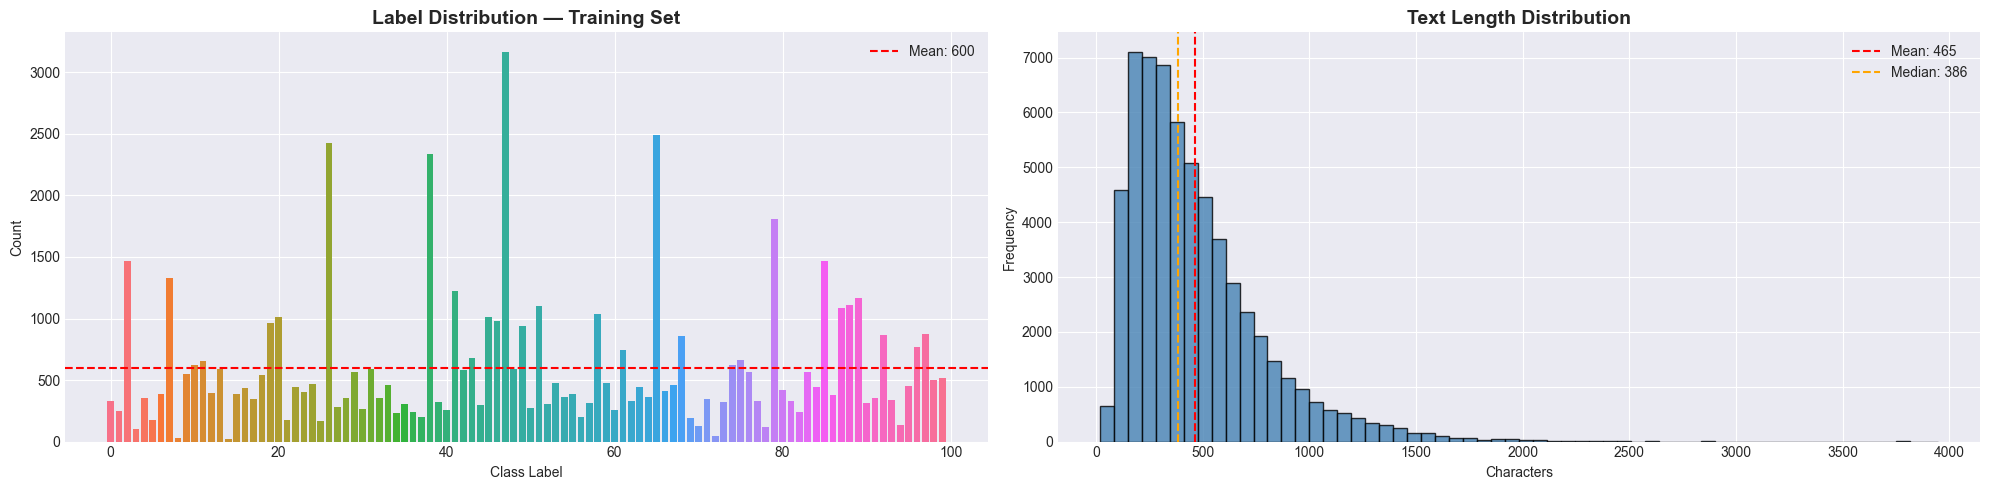

Classes: 100
Imbalance ratio (max/min): 137.7x
count     100.000000
mean      600.000000
std       538.173811
min        23.000000
25%       311.750000
50%       426.500000
75%       667.250000
max      3167.000000
Name: count, dtype: float64


In [11]:
label_counts = train_df['label'].value_counts().sort_index()
train_df['text_length'] = train_df['text'].apply(len)

fig, axes = plt.subplots(1, 2, figsize=(20, 5))

axes[0].bar(label_counts.index, label_counts.values,
            color=sns.color_palette('husl', len(label_counts)))
axes[0].axhline(label_counts.mean(), color='red', linestyle='--',
                label=f'Mean: {label_counts.mean():.0f}')
axes[0].set_title('Label Distribution — Training Set', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Class Label'); axes[0].set_ylabel('Count'); axes[0].legend()

axes[1].hist(train_df['text_length'], bins=60, color='steelblue', edgecolor='black', alpha=0.8)
axes[1].axvline(train_df['text_length'].mean(), color='red', linestyle='--',
                label=f'Mean: {train_df["text_length"].mean():.0f}')
axes[1].axvline(train_df['text_length'].median(), color='orange', linestyle='--',
                label=f'Median: {train_df["text_length"].median():.0f}')
axes[1].set_title('Text Length Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Characters'); axes[1].set_ylabel('Frequency'); axes[1].legend()

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Classes: {train_df['label'].nunique()}")
print(f"Imbalance ratio (max/min): {label_counts.max()/label_counts.min():.1f}x")
print(label_counts.describe())


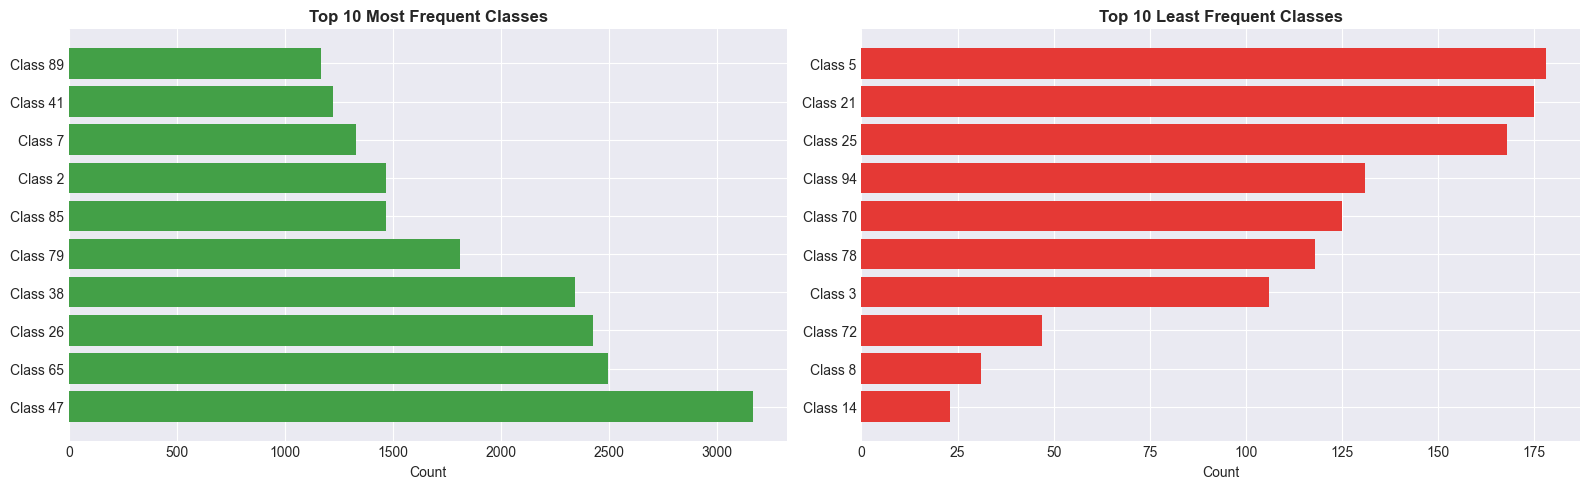

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

top10    = label_counts.nlargest(10)
bottom10 = label_counts.nsmallest(10)

axes[0].barh(range(10), top10.values, color='#43a047')
axes[0].set_yticks(range(10)); axes[0].set_yticklabels([f'Class {i}' for i in top10.index])
axes[0].set_title('Top 10 Most Frequent Classes', fontweight='bold')
axes[0].set_xlabel('Count')

axes[1].barh(range(10), bottom10.values, color='#e53935')
axes[1].set_yticks(range(10)); axes[1].set_yticklabels([f'Class {i}' for i in bottom10.index])
axes[1].set_title('Top 10 Least Frequent Classes', fontweight='bold')
axes[1].set_xlabel('Count')

plt.tight_layout(); plt.show()


## 3. Preprocessing & Feature Engineering

In [13]:
X_train, y_train = train_df['text'], train_df['label']
X_val,   y_val   = val_df['text'],   val_df['label']
X_test,  y_test  = test_df['text'],  test_df['label']

classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights = dict(zip(classes.tolist(), weights.tolist()))

print(f"Class weights computed for {len(class_weights)} classes.")
print(f"Weight range: [{min(class_weights.values()):.2f}, {max(class_weights.values()):.2f}]")

# Save weights
with open('class_weights.json', 'w') as f:
    json.dump(class_weights, f, indent=4)
print("class_weights.json saved.")


Class weights computed for 100 classes.
Weight range: [0.19, 26.09]
class_weights.json saved.


## 4. Baseline Model
Logistic Regression with default C=1.0 and TF-IDF (5000 features).


In [14]:
t0 = time.time()

baseline_vec = TfidfVectorizer(max_features=5000)
X_tr_b = baseline_vec.fit_transform(X_train)
X_v_b  = baseline_vec.transform(X_val)

baseline_model = LogisticRegression(
    C=1.0, class_weight=class_weights,
    max_iter=1000, solver='lbfgs',
    n_jobs=-1
)
baseline_model.fit(X_tr_b, y_train)

baseline_preds = baseline_model.predict(X_v_b)
baseline_f1    = f1_score(y_val, baseline_preds, average='macro')

print(f"Baseline Macro F1 (Validation): {baseline_f1:.4f}")
print(f"Time: {time.time()-t0:.1f}s")


Baseline Macro F1 (Validation): 0.7621
Time: 44.9s


## 5. PSO Hyperparameter Optimization

**Particle Swarm Optimization** is a metaheuristic inspired by the social behaviour of birds.
Each **particle** is a candidate solution (pair of hyperparameters); the swarm converges towards the global optimum.

| Parameter | Search Space | Meaning |
|-----------|-------------|---------|
| `log₁₀(C)` | [−2, 3] | LR regularisation strength |
| `max_features` | [3 000, 15 000] | TF-IDF vocabulary size |

**Objective**: Minimise **−Macro F1** on the validation set.


In [15]:
# 25 % stratified subsample for faster PSO particle evaluation
sss = StratifiedShuffleSplit(n_splits=1, train_size=0.25, random_state=42)
for idx, _ in sss.split(X_train, y_train):
    X_pso, y_pso = X_train.iloc[idx], y_train.iloc[idx]

pso_classes  = np.unique(y_pso)
pso_weights  = compute_class_weight('balanced', classes=pso_classes, y=y_pso)
pso_cw       = dict(zip(pso_classes.tolist(), pso_weights.tolist()))

print(f"PSO subset: {len(X_pso):,} samples ({len(X_pso)/len(X_train)*100:.0f}% of train)")
print(f"Evaluation: full validation set ({len(X_val):,} samples)")


PSO subset: 15,000 samples (25% of train)
Evaluation: full validation set (10,000 samples)


In [16]:
pso_log = []   # track best F1 per iteration call

def objective(particles):
    """
    particles : ndarray (n_particles, 2)
        col 0 -> log10(C)
        col 1 -> max_features (float, cast to int)
    Returns negative Macro-F1 for each particle.
    """
    costs = np.zeros(particles.shape[0])
    for i, p in enumerate(particles):
        C_val   = 10 ** p[0]
        n_feat  = max(1000, int(p[1]))
        try:
            vec  = TfidfVectorizer(max_features=n_feat)
            Xtr  = vec.fit_transform(X_pso)
            Xv   = vec.transform(X_val)
            clf  = LogisticRegression(C=C_val, class_weight=pso_cw,
                                      max_iter=400, solver='lbfgs',
                                      n_jobs=-1)
            clf.fit(Xtr, y_pso)
            f1   = f1_score(y_val, clf.predict(Xv), average='macro', zero_division=0)
            costs[i] = -f1
        except Exception:
            costs[i] = 0.0
    best = -np.min(costs)
    pso_log.append(best)
    print(f"  batch done | best F1 in batch: {best:.4f}")
    return costs

print("Objective function ready.")


Objective function ready.


In [17]:
options = {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
bounds  = (np.array([-2.0, 3000.0]),
           np.array([ 3.0, 15000.0]))

optimizer = GlobalBestPSO(n_particles=10, dimensions=2,
                          options=options, bounds=bounds)

print("=" * 55)
print(" Running PSO  (n_particles=10, iters=15)")
print("=" * 55)

t0 = time.time()
best_cost, best_pos = optimizer.optimize(objective, iters=15, verbose=True)
pso_time = time.time() - t0

best_C            = 10 ** best_pos[0]
best_max_features = int(best_pos[1])

print(f"\n{'='*55}")
print(f" Best Macro F1 (PSO, val-subset): {-best_cost:.4f}")
print(f" Best C                         : {best_C:.5f}")
print(f" Best max_features              : {best_max_features}")
print(f" PSO wall-time                  : {pso_time:.1f}s")
print(f"{'='*55}")


2026-04-21 21:08:10,018 - pyswarms.single.global_best - INFO - Optimize for 15 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}


 Running PSO  (n_particles=10, iters=15)


pyswarms.single.global_best:   7%|▋         |1/15, best_cost=-0.738

  batch done | best F1 in batch: 0.7382


pyswarms.single.global_best:  13%|█▎        |2/15, best_cost=-0.738

...

  batch done | best F1 in batch: 0.7427


pyswarms.single.global_best:  93%|█████████▎|14/15, best_cost=-0.744

  batch done | best F1 in batch: 0.7437


pyswarms.single.global_best: 100%|██████████|15/15, best_cost=-0.745
2026-04-21 21:42:31,147 - pyswarms.single.global_best - INFO - Optimization finished | best cost: -0.7447611193252837, best pos: [2.36615709e+00 4.90714115e+03]


  batch done | best F1 in batch: 0.7448

 Best Macro F1 (PSO, val-subset): 0.7448
 Best C                         : 232.35771
 Best max_features              : 4907
 PSO wall-time                  : 2061.1s


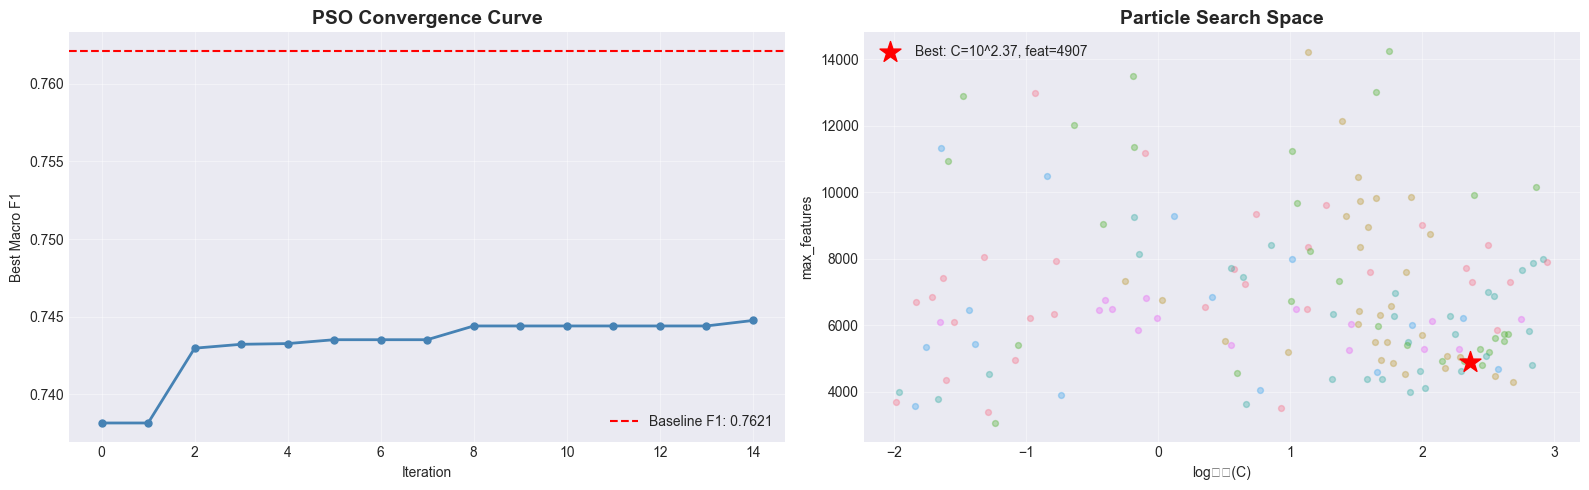

In [18]:
cost_hist = [-c for c in optimizer.cost_history]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Convergence curve
axes[0].plot(cost_hist, marker='o', color='steelblue', linewidth=2, markersize=5)
axes[0].axhline(baseline_f1, color='red', linestyle='--',
                label=f'Baseline F1: {baseline_f1:.4f}')
axes[0].set_title('PSO Convergence Curve', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Iteration'); axes[0].set_ylabel('Best Macro F1')
axes[0].legend(); axes[0].grid(alpha=0.4)

# Particle positions
pos_hist = np.array(optimizer.pos_history)   # (iters, n_particles, 2)
for p in range(pos_hist.shape[1]):
    axes[1].scatter(pos_hist[:, p, 0], pos_hist[:, p, 1], alpha=0.35, s=18)
axes[1].scatter(best_pos[0], best_pos[1], color='red', s=250,
                zorder=10, marker='*',
                label=f'Best: C=10^{best_pos[0]:.2f}, feat={best_max_features}')
axes[1].set_title('Particle Search Space', fontsize=14, fontweight='bold')
axes[1].set_xlabel('log₁₀(C)'); axes[1].set_ylabel('max_features')
axes[1].legend(); axes[1].grid(alpha=0.4)

plt.tight_layout()
plt.savefig('pso_convergence.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Final Model Training
Retrain on the **full** training set with PSO-optimal hyperparameters.


In [19]:
print(f"Hyperparameters → C={best_C:.5f}, max_features={best_max_features}")
t0 = time.time()

final_vec   = TfidfVectorizer(max_features=best_max_features)
X_tr_f      = final_vec.fit_transform(X_train)
X_val_f     = final_vec.transform(X_val)
X_test_f    = final_vec.transform(X_test)

final_model = LogisticRegression(
    C=best_C, class_weight=class_weights,
    max_iter=1000, solver='lbfgs',
    n_jobs=-1
)
final_model.fit(X_tr_f, y_train)

val_preds  = final_model.predict(X_val_f)
test_preds = final_model.predict(X_test_f)

val_f1  = f1_score(y_val,  val_preds,  average='macro')
test_f1 = f1_score(y_test, test_preds, average='macro')

print(f"\nBaseline Macro F1 (val) : {baseline_f1:.4f}")
print(f"Final    Macro F1 (val) : {val_f1:.4f}  ({(val_f1-baseline_f1)*100:+.2f}%)")
print(f"Final    Macro F1 (test): {test_f1:.4f}")
print(f"Training time: {time.time()-t0:.1f}s")


Hyperparameters → C=232.35771, max_features=4907

Baseline Macro F1 (val) : 0.7621
Final    Macro F1 (val) : 0.7786  (+1.65%)
Final    Macro F1 (test): 0.7873
Training time: 74.3s


In [20]:
import os
os.makedirs('../model', exist_ok=True)

joblib.dump(final_model,  '../model/logistic_regression_pso.pkl')
joblib.dump(final_vec,    '../model/tfidf_vectorizer.pkl')
with open('../model/best_params.json', 'w') as f:
    json.dump({'C': best_C, 'max_features': best_max_features,
               'val_macro_f1': val_f1, 'test_macro_f1': test_f1}, f, indent=4)

print("Model, vectorizer & params saved to ../model/")


Model, vectorizer & params saved to ../model/


## 7. Results Visualisation

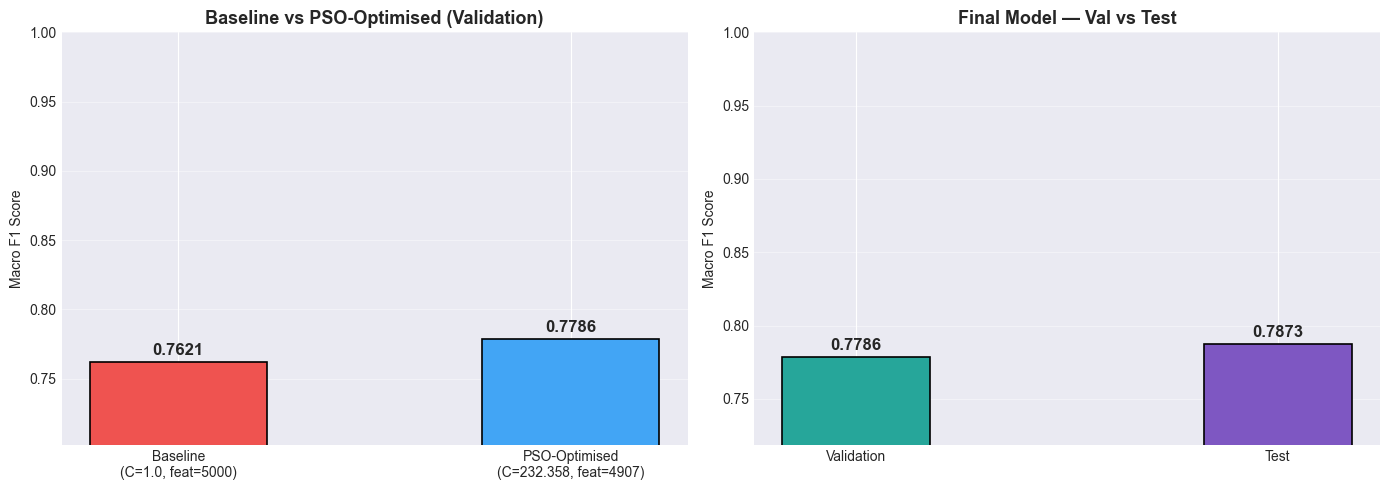

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: Baseline vs Final ────────────────────────────────────────────────────
labels_cmp = ['Baseline\n(C=1.0, feat=5000)',
               f'PSO-Optimised\n(C={best_C:.3f}, feat={best_max_features})']
scores_cmp = [baseline_f1, val_f1]
colors_cmp = ['#ef5350', '#42a5f5']

bars = axes[0].bar(labels_cmp, scores_cmp, color=colors_cmp,
                   width=0.45, edgecolor='black', linewidth=1.2)
for bar, s in zip(bars, scores_cmp):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.003,
                 f'{s:.4f}', ha='center', va='bottom',
                 fontweight='bold', fontsize=12)
axes[0].set_title('Baseline vs PSO-Optimised (Validation)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Macro F1 Score')
axes[0].set_ylim([min(scores_cmp) - 0.06, 1.0])
axes[0].grid(axis='y', alpha=0.4)

# ── Right: Val vs Test for final model ─────────────────────────────────────────
labels_vt  = ['Validation', 'Test']
scores_vt  = [val_f1, test_f1]
colors_vt  = ['#26a69a', '#7e57c2']

bars2 = axes[1].bar(labels_vt, scores_vt, color=colors_vt,
                    width=0.35, edgecolor='black', linewidth=1.2)
for bar, s in zip(bars2, scores_vt):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.003,
                 f'{s:.4f}', ha='center', va='bottom',
                 fontweight='bold', fontsize=12)
axes[1].set_title('Final Model — Val vs Test', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Macro F1 Score')
axes[1].set_ylim([min(scores_vt) - 0.06, 1.0])
axes[1].grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


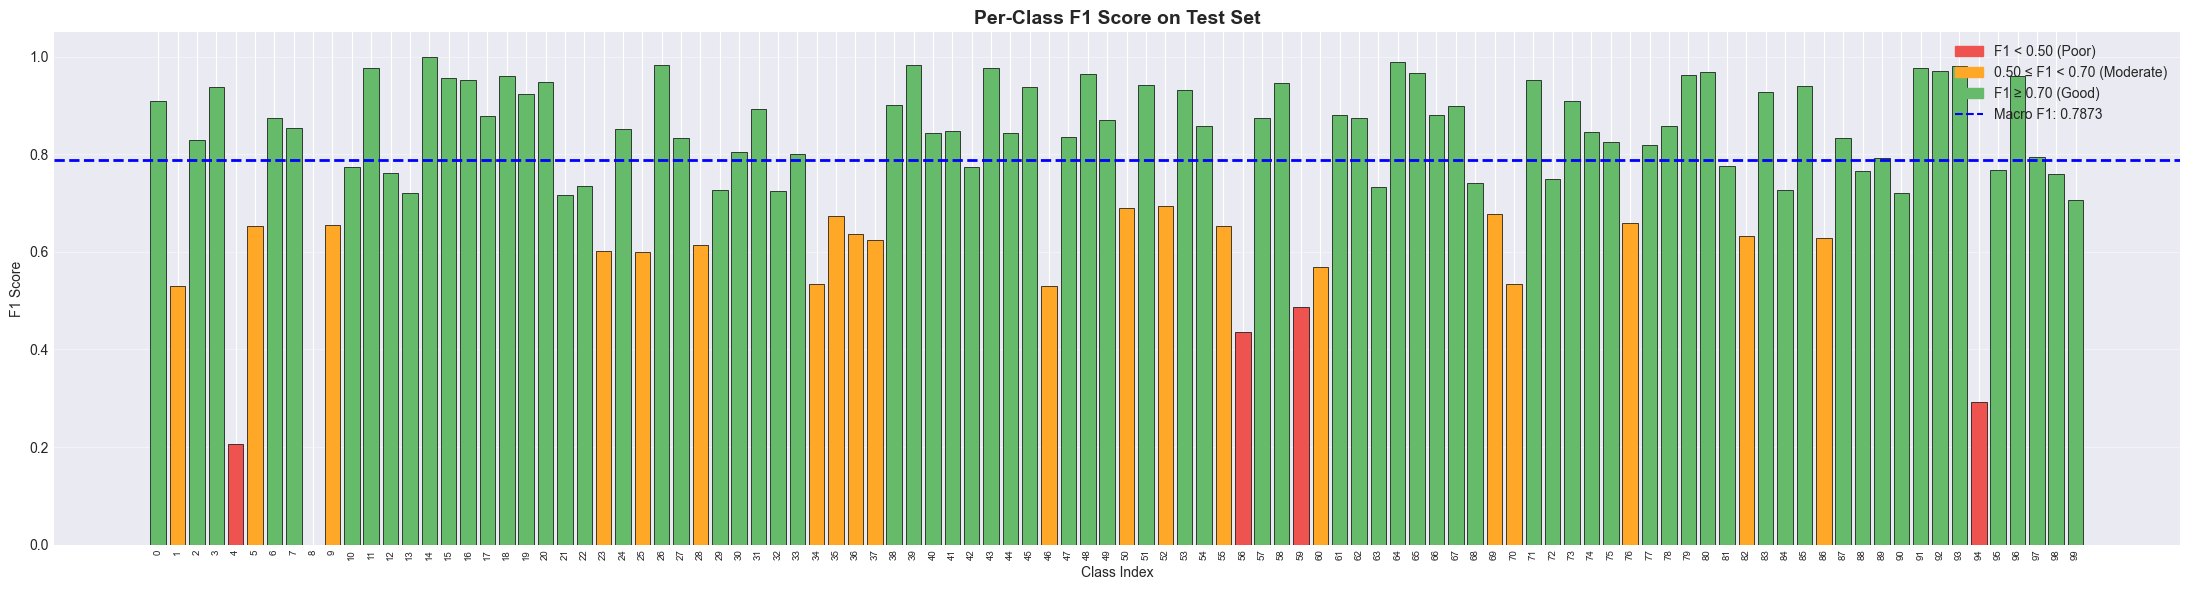


Worst 10 classes:
    8  Assigns                              F1=0.0000
    4  Applicable Laws                      F1=0.2069
   94  Venues                               F1=0.2927
   56  Jurisdictions                        F1=0.4348
   59  Miscellaneous                        F1=0.4861
    1  Agreements                           F1=0.5301
   46  General                              F1=0.5307
   34  Effectiveness                        F1=0.5333
   70  Powers                               F1=0.5333
   60  Modifications                        F1=0.5684


In [22]:
LABEL_NAMES = [
    'Adjustments','Agreements','Amendments','Anti-Corruption Laws','Applicable Laws',
    'Approvals','Arbitration','Assignments','Assigns','Authority','Authorizations',
    'Base Salary','Benefits','Binding Effects','Books','Brokers','Capitalization',
    'Change In Control','Closings','Compliance With Laws','Confidentiality',
    'Consent To Jurisdiction','Consents','Construction','Cooperation','Costs',
    'Counterparts','Death','Defined Terms','Definitions','Disability','Disclosures',
    'Duties','Effective Dates','Effectiveness','Employment','Enforceability',
    'Enforcements','Entire Agreements','Erisa','Existence','Expenses','Fees',
    'Financial Statements','Forfeitures','Further Assurances','General',
    'Governing Laws','Headings','Indemnifications','Indemnity','Insurances',
    'Integration','Intellectual Property','Interests','Interpretations','Jurisdictions',
    'Liens','Litigations','Miscellaneous','Modifications','No Conflicts','No Defaults',
    'No Waivers','Non-Disparagement','Notices','Organizations','Participations',
    'Payments','Positions','Powers','Publicity','Qualifications','Records','Releases',
    'Remedies','Representations','Sales','Sanctions','Severability','Solvency',
    'Specific Performance','Submission To Jurisdiction','Subsidiaries','Successors',
    'Survival','Tax Withholdings','Taxes','Terminations','Terms','Titles',
    'Transactions With Affiliates','Use Of Proceeds','Vacations','Venues','Vesting',
    'Waiver Of Jury Trials','Waivers','Warranties','Withholdings'
]

report     = classification_report(y_test, test_preds, output_dict=True, zero_division=0)
pc_f1      = pd.Series({int(k): v['f1-score']
                         for k, v in report.items() if k.isdigit()}).sort_index()

bar_colors = ['#ef5350' if v < 0.5 else '#ffa726' if v < 0.7 else '#66bb6a'
              for v in pc_f1.values]

fig, ax = plt.subplots(figsize=(22, 6))
ax.bar(range(len(pc_f1)), pc_f1.values, color=bar_colors, edgecolor='black', linewidth=0.5)
ax.axhline(test_f1, color='blue', linestyle='--', linewidth=2,
           label=f'Macro F1: {test_f1:.4f}')
ax.set_title('Per-Class F1 Score on Test Set', fontsize=14, fontweight='bold')
ax.set_xlabel('Class Index'); ax.set_ylabel('F1 Score')
ax.set_xticks(range(len(pc_f1))); ax.set_xticklabels(pc_f1.index, rotation=90, fontsize=7)
ax.set_ylim([0, 1.05]); ax.grid(axis='y', alpha=0.4)

patches = [
    mpatches.Patch(color='#ef5350', label='F1 < 0.50 (Poor)'),
    mpatches.Patch(color='#ffa726', label='0.50 ≤ F1 < 0.70 (Moderate)'),
    mpatches.Patch(color='#66bb6a', label='F1 ≥ 0.70 (Good)'),
    plt.Line2D([0],[0], color='blue', linestyle='--', label=f'Macro F1: {test_f1:.4f}'),
]
ax.legend(handles=patches, fontsize=10)
plt.tight_layout()
plt.savefig('per_class_f1.png', dpi=150, bbox_inches='tight')
plt.show()

worst = pc_f1.nsmallest(10)
print("\nWorst 10 classes:")
for idx, val in worst.items():
    name = LABEL_NAMES[idx] if idx < len(LABEL_NAMES) else f'Class {idx}'
    print(f"  {idx:3d}  {name:<35s}  F1={val:.4f}")


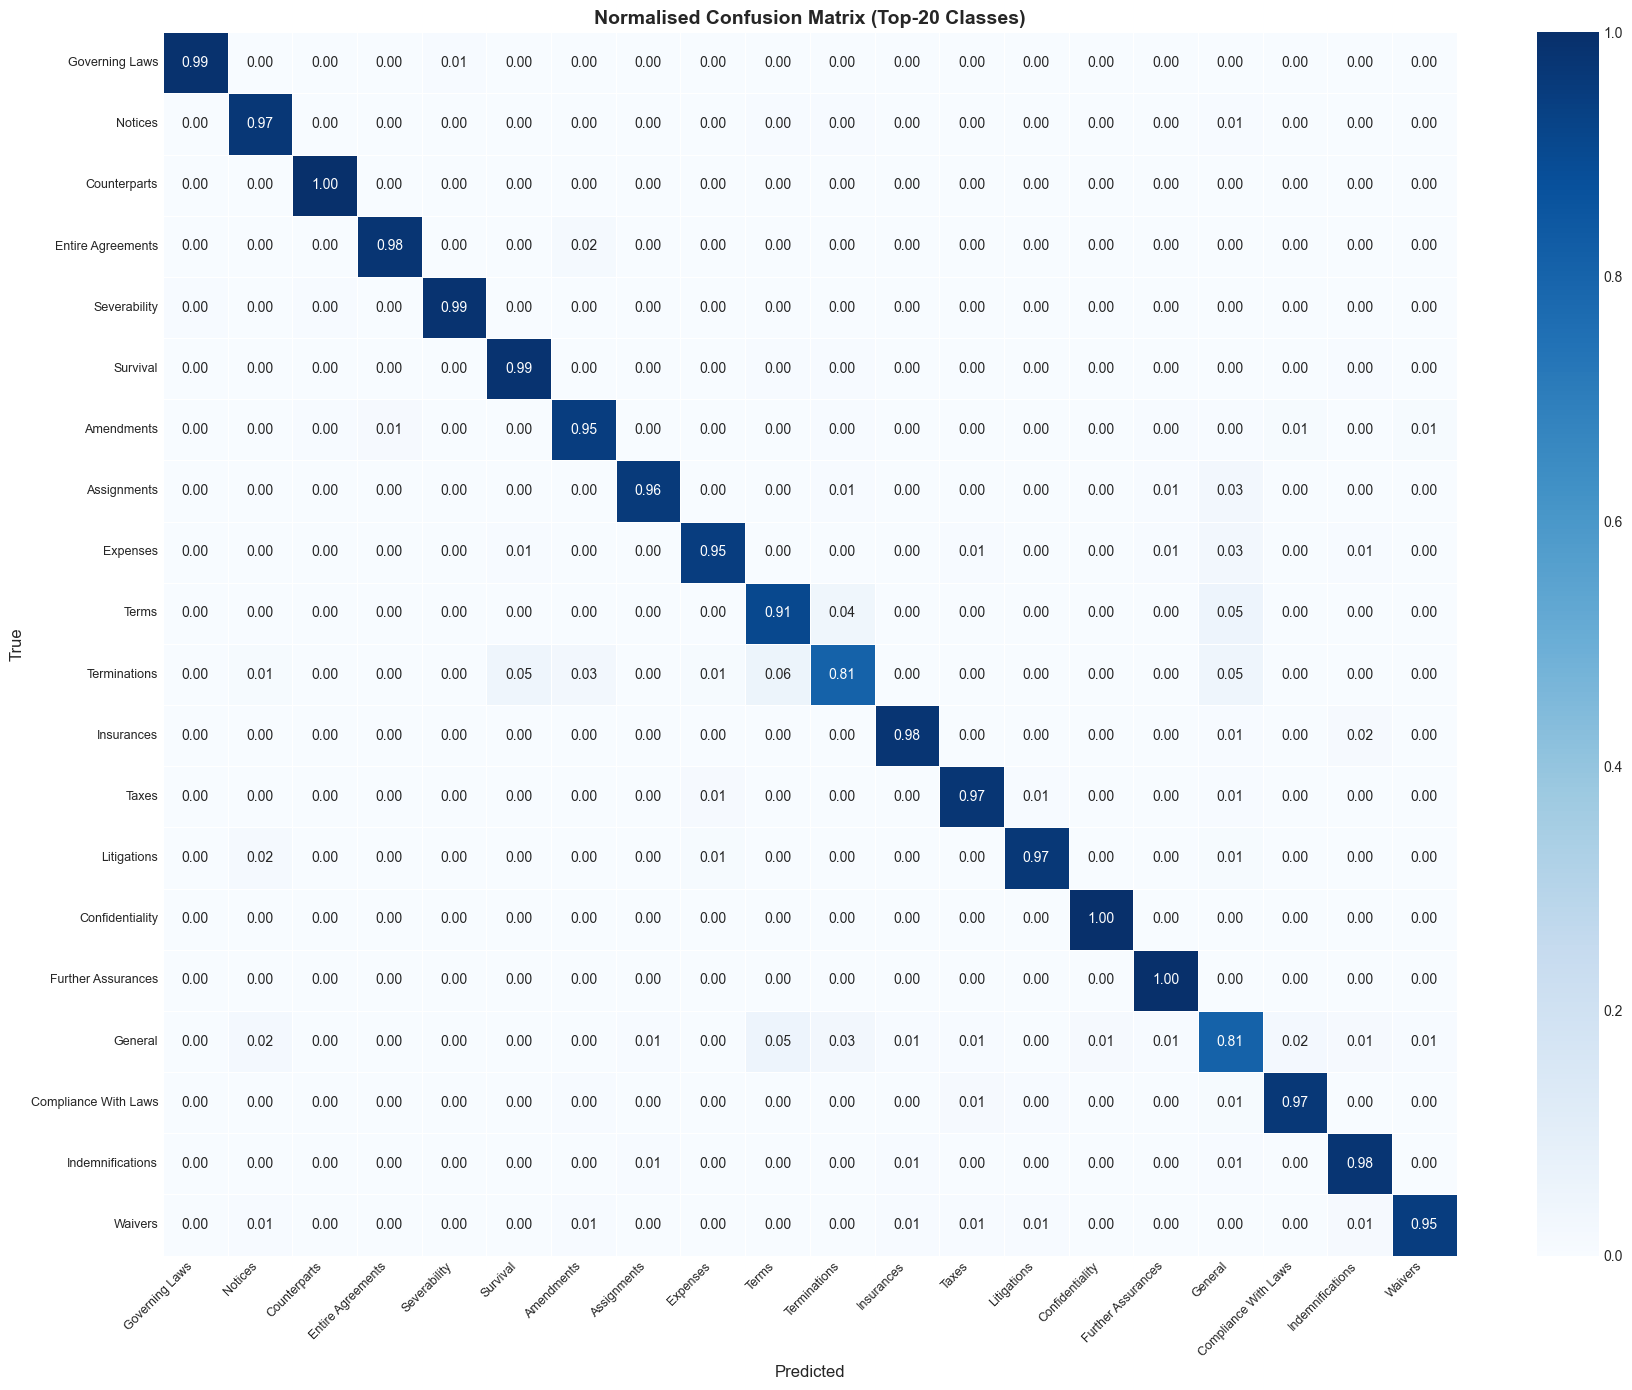

In [23]:
# Confusion matrix for the 20 most frequent classes
top20 = label_counts.nlargest(20).index.tolist()

mask  = y_test.isin(top20)
yt20  = y_test[mask]
yp20  = pd.Series(test_preds, index=y_test.index)[mask]

cm20  = confusion_matrix(yt20, yp20, labels=top20, normalize='true')
names20 = [LABEL_NAMES[i] if i < len(LABEL_NAMES) else str(i) for i in top20]

fig, ax = plt.subplots(figsize=(18, 14))
sns.heatmap(cm20, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=names20, yticklabels=names20,
            linewidths=0.5, ax=ax)
ax.set_title('Normalised Confusion Matrix (Top-20 Classes)', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted', fontsize=12); ax.set_ylabel('True', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('confusion_matrix_top20.png', dpi=150, bbox_inches='tight')
plt.show()


In [24]:
print("=" * 60)
print(" FINAL RESULTS SUMMARY")
print("=" * 60)
print(f"  Dataset          : LEDGAR (coastalchp/ledgar)")
print(f"  Classes          : 100")
print(f"  Train samples    : {len(X_train):,}")
print(f"  Val samples      : {len(X_val):,}")
print(f"  Test samples     : {len(X_test):,}")
print()
print(f"  Feature          : TF-IDF (max_features={best_max_features})")
print(f"  Classifier       : Logistic Regression (C={best_C:.5f})")
print(f"  Optimisation     : PSO (n_particles=10, iters=15)")
print()
print(f"  Baseline F1 (val): {baseline_f1:.4f}")
print(f"  Final F1 (val)   : {val_f1:.4f}  ({(val_f1-baseline_f1)*100:+.2f}%)")
print(f"  Final F1 (test)  : {test_f1:.4f}")
print("=" * 60)


 FINAL RESULTS SUMMARY
  Dataset          : LEDGAR (coastalchp/ledgar)
  Classes          : 100
  Train samples    : 60,000
  Val samples      : 10,000
  Test samples     : 10,000

  Feature          : TF-IDF (max_features=4907)
  Classifier       : Logistic Regression (C=232.35771)
  Optimisation     : PSO (n_particles=10, iters=15)

  Baseline F1 (val): 0.7621
  Final F1 (val)   : 0.7786  (+1.65%)
  Final F1 (test)  : 0.7873
